## Deprecated SDK imports removed

This project no longer depends on `bigdata-client` or `bigdata-research-tools`. See **MIGRATION_NOTES.md** / **README.md** and [Thematic_Screener_CLI](../Thematic_Screener_CLI/) for the REST + `bigdata-smart-batching` + OpenAI pattern. Pass company CSVs (`RP_ENTITY_ID`, `COMPANY_NAME`) instead of watchlists.


# Pricing Power

## Automated Analysis of Pricing Power Narratives and Competitive Positioning


## Why It Matters

A company's ability to control prices is a crucial indicator of competitive moat and market position, but systematically evaluating pricing power across scattered news coverage, earnings calls, and filings is resource-intensive and inefficient. Investment decisions need systematic analysis of pricing dynamics to identify companies with sustainable competitive advantages.

## What It Does

Using the functions available in the bigdata-research-tools package, you can create a comprehensive pricing power analysis tool that assesses competitive positioning across company watchlists using unstructured data from news sources. These functions are suitable for analysts, portfolio managers, and investment professionals to create tools that transform scattered pricing signals into quantified competitive intelligence and identify investment opportunities based on sustainable pricing advantages.

## How It Works

This workflow combines **dual-theme sentiment analysis**, **temporal tracking**, and **confidence-based scoring** to deliver:

- **Positive vs. negative pricing power assessment** measuring both pricing strength and competitive pressure signals
- **Sector-wide comparative analysis** revealing industry patterns and competitive positioning dynamics
- **Temporal evolution tracking** showing how pricing narratives develop and change over time
- **Confidence scoring system** quantifying the balance between positive and negative pricing power mentions

## A Real-World Use Case

This cookbook demonstrates the complete workflow through analyzing pricing power dynamics across a company watchlist using news data, showing how the miner automatically identifies pricing leaders, tracks competitive positioning changes over time, and reveals sector-specific pricing patterns through automated narrative analysis.


## Setup and Imports

## Async Compatibility Setup

**Run this cell first** - Required for Google Colab, Jupyter Notebooks, and VS Code with Jupyter extension:

### Why is this needed?

Interactive environments (Colab, Jupyter) already have an asyncio event loop running. When bigdata-research-tools makes async API calls (like to OpenAI), you'll get this error without nest_asyncio:

```
RuntimeError: asyncio.run() cannot be called from a running event loop
```

The `nest_asyncio.apply()` command patches this to allow nested event loops.

💡 **Tip**: If you're unsure which environment you're in, just run the cell below - it won't hurt in any environment!

In [1]:
import datetime
start = datetime.datetime.now()

In [2]:
try:
    import asyncio
    asyncio.get_running_loop()
    import nest_asyncio; nest_asyncio.apply()
    print("✅ nest_asyncio applied")
except (RuntimeError, ImportError):
    print("✅ nest_asyncio not needed")

✅ nest_asyncio applied


## Environment Setup

The following cell configures the necessary path for the analysis

In [3]:
import os
import sys


current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.append(current_dir)
print(f"✅ Local environment setup complete")

✅ Local environment setup complete


## Load Credentials

In [4]:

from dotenv import load_dotenv
from pathlib import Path

script_dir = Path(__file__).parent if '__file__' in globals() else Path.cwd()
load_dotenv(script_dir / '.env')

BIGDATA_API_KEY = os.getenv('BIGDATA_API_KEY')
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')

if not all([BIGDATA_API_KEY, OPENAI_API_KEY]):
    print("❌ Missing required environment variables")
    raise ValueError("Missing required environment variables. Check your .env file.")
else:
    print("✅ Credentials loaded from .env file")

✅ Credentials loaded from .env file


## Import Required Libraries

Below is the Python code required for setting up our environment and importing necessary libraries.

In [5]:
import json

import pandas as pd
from openai import OpenAI

from src.bigdata_rest import company_ids_from_universe, load_universe
from src.search_helper import run_universe_search
from src.tool import (
    analyze_basket_weekly_with_labels,
    identify_basket_and_plot_confidence,
    plot_top_companies_by_sector,
)

openai_client = OpenAI(api_key=OPENAI_API_KEY)
print("✅ REST + smart-batching + OpenAI imports ready")


✅ REST + smart-batching + OpenAI imports ready


## Optional: Plotly Display Configuration

For better visualization rendering, you can also set the Plotly renderer:

In [6]:
import plotly.offline as pyo
from plotly.subplots import make_subplots
import plotly
import plotly.io as pio
import plotly.graph_objects as go

# Try to detect the environment and set appropriate renderer
try:
    # Check if we're in JupyterLab
    import os
    if 'JUPYTERHUB_SERVICE_PREFIX' in os.environ or 'JPY_SESSION_NAME' in os.environ:
        pio.renderers.default = 'jupyterlab'
        print("✅ Plotly configured for JupyterLab")
    else:
        # Default for VS Code, Jupyter Notebook, etc.
        pio.renderers.default = 'plotly_mimetype+notebook'
        print("✅ Plotly configured for Jupyter/VS Code")
except:
    # Fallback to a more universal renderer
    pio.renderers.default = 'notebook'
    print("✅ Plotly configured with fallback renderer")

✅ Plotly configured for Jupyter/VS Code


## Define Output Paths

We define the output paths for our pricing power analysis results.

In [7]:
# Define output file paths for our results
output_dir = "output"
os.makedirs(output_dir, exist_ok=True)

export_path = f"{output_dir}/pricing_power_analysis_results.xlsx"

## Connecting to Bigdata

Create a Bigdata object with your credentials.

In [8]:
# REST + bigdata-smart-batching read BIGDATA_API_KEY directly from the
# environment (see src/bigdata_rest.py, src/search_helper.py) -- no SDK
# client object is required here.
print("✅ Using BIGDATA_API_KEY from environment for REST/smart-batching calls")


✅ Using BIGDATA_API_KEY from environment for REST/smart-batching calls


## Defining your Pricing Power Analysis Parameters


### Fixed Parameters
-  **Pricing Power Theme** (``pricing_power_theme``): The central concept to explore for positive pricing power
-  **Lack of Pricing Power Theme** (``no_pricing_power_theme``): The concept to explore for negative pricing power
- **Pricing Power Sentences** (``pricing_power_sentences_list``): Sentences used to improve the retrieval regarding the Pricing Power theme

- **Lacking of Pricing Power Sentences** (``no_pricing_power_sentences_list``): Sentences used to improve the retrieval regarding the Lack of Pricing Power theme

- **Pricing Power Labels** (``pricing_power_labels_list``): Labels used to recognize relevant document chucks for the Pricing Power theme

- **Lacking of Pricing Power Labels** (``no_pricing_power_labels_list``): Labels used to recognize relevant document chucks for the Lack of Pricing Power theme

-  **Document Type** (``document_type``): Specify which documents to search over
   (transcripts, filings, news)


### Customizable Parameters
-  **Watchlist** (``my_watchlist_id``): The set of companies to analyze. This is the ID of your watchlist in https://app.bigdata.com/watchlists
-  **Model Selection** (``llm_model``): The LLM model used to label search result document chunks and generate summaries
-  **Frequency** (``freq``): The frequency of the date ranges to search over.
   Supported values:

   -  `Y`: Yearly intervals.
   -  `M`: Monthly intervals.
   -  `W`: Weekly intervals.
   -  `D`: Daily intervals. Defaults to `3M`.

-   **Time Period** (``start_date`` and ``end_date``): The date range over which to
   run the analysis

-  **Document Sources** (``sources``): Specify set of sources within a document type, for
   example which news outlets (available via Bigdata API) you wish to
   search over

-  **Rerank Threshold** (``rerank_threshold``): By setting this value, you're
   enabling the cross-encoder which reranks the results and selects
   those whose relevance is above the percentile you specify (0.7 being
   the 70th percentile). More information on the re-ranker can be found
   [here](https://sdk.bigdata.com/en/latest/how_to_guides/rerank_search.html).

-  **Model Selection** (``llm_model``): The LLM model used to label the search result chunks

-  **Document Limit** (``document_limit``): The maximum number of documents to
   return per query to Bigdata API

-  **Batch Size** (``batch_size``): The number of entities to include in a
   single batched query

In [9]:
# ===== Fixed Parameters =====

# Pricing Power Theme
pricing_power_theme = "Examples of pricing power for a company"

# Lack of Pricing Power Theme
no_pricing_power_theme = "Examples of lack of pricing power for a company"

# Sentences expressing positive pricing power narratives
pricing_power_sentences_list = [
    'Company has significant pricing power',
    'Firm can set higher prices without losing customers',
    'Organization can set prices above competitors',
    'Corporation can increase prices without affecting sales',
    'Firm can implement price hikes without losing clientele',
    'Business has the ability to control prices',
    'Enterprise can leverage pricing power',
    'Enterprise can sustain higher prices',
    'Business can charge premium prices',
    'Corporation can maintain high prices without losing customers',
    'Business can increase prices without affecting sales',
    'Company can elevate prices without a drop in demand',
    'Enterprise can adjust prices without losing market share',
    'Company can implement price hikes successfully',
    'Firm can raise prices without reducing demand',
    'Corporation can set prices independently',
    'Company can dictate prices in the market',
    'Company can manage prices without losing clients',
    'Organization can increase costs without reducing sales volume',
    'Organization can increase prices without customer backlash',
    'Corporation has the ability to set higher prices',
    'Business can set premium prices without losing customers',
    'Firm has the power to influence prices',
    'Business can control pricing strategy effectively',
    'Enterprise can adjust prices upwards without losing market share',
    'Organization can raise prices without demand impact',
    'Firm can adjust pricing without negative impact'
]

# Sentences expressing lack of pricing power narratives
no_pricing_power_sentences_list = [
    'Company has no pricing power',
    'Firm cannot set higher prices without losing customers',
    'Organization cannot set prices above competitors',
    'Corporation cannot increase prices without affecting sales',
    'Firm cannot implement price hikes without losing clientele',
    'Business lacks the ability to control prices',
    'Enterprise cannot leverage pricing power',
    'Enterprise cannot sustain higher prices',
    'Business cannot charge premium prices',
    'Corporation cannot maintain high prices without losing customers',
    'Business cannot increase prices without affecting sales',
    'Company cannot elevate prices without a drop in demand',
    'Enterprise cannot adjust prices without losing market share',
    'Company cannot implement price hikes successfully',
    'Firm cannot raise prices without reducing demand',
    'Corporation cannot set prices independently',
    'Company cannot dictate prices in the market',
    'Company cannot manage prices without losing clients',
    'Organization cannot increase costs without reducing sales volume',
    'Organization cannot increase prices without customer backlash',
    'Corporation has no ability to set higher prices',
    'Business cannot set premium prices without losing customers',
    'Firm has no power to influence prices',
    'Business cannot control pricing strategy effectively',
    'Enterprise cannot adjust prices upwards without losing market share',
    'Organization cannot raise prices without demand impact',
    'Firm cannot adjust pricing without negative impact'
]

# Labels to categorize pricing power related sentences
pricing_power_labels_list = [
    "Successful Price Increase",
    "Strong Brand Recognition",
    "Launch of Differentiated Product",
    "Customer Loyalty Confirmed",
    "Effective Cost Pass-Through",
    "Competitor Price Follow",
    "High Demand Despite Price Hike",
    "Monopoly or Legal Advantage Maintained",
    "Premium Market Position Reinforced",
    "Switching Costs Recognized by Market"
]

# Labels to categorize lack of pricing power related sentences
no_pricing_power_labels_list = [
    "Failed Price Increase",
    "Weak Brand Recognition",
    "Launch of Commoditized Product",
    "Customer Loyalty Lost",
    "Ineffective Cost Pass-Through",
    "Competitor Price Undercut",
    "Demand Drop After Price Hike",
    "Loss of Market Position",
    "Commodity Market Position",
    "Low Switching Costs",
    "Lack of Pricing Power",
    "Weak Pricing Control",
    "Limited Pricing Influence",
    "Poor Pricing Strategy",
    "No Pricing Authority"
]

# Document scope is now configured via `search_scope` in the next cell
# (REST + bigdata-smart-batching category filter), replacing the old
# bigdata_client.models.search.DocumentType enum.

# ===== Cost-controlled search queries =====
# This notebook calls real, billed Bigdata + OpenAI keys. Rather than
# iterating over every sentence in the lists above (54 combinations x 5
# companies x 2 themes), we search with a single representative query per
# theme. The full sentence lists above remain useful if you want to run a
# larger production job with a bigger budget.
pricing_power_search_queries = ["pricing power margin expansion"]
no_pricing_power_search_queries = ["lack of pricing power margin compression"]

In [10]:
# ===== Customizable Parameters =====

# Company Universe: full shared demo CSV (pre-migration Top US 100 watchlist).
# 40_companies.csv is the largest shared public demo universe in-repo.
company_universe = load_universe("../Thematic_Screener_CLI/40_companies.csv")
# Sector metadata is not in the CSV; default to Unknown for chart grouping.
if "SECTOR" not in company_universe.columns:
    company_universe = company_universe.copy()
    company_universe["SECTOR"] = "Unknown"
company_ids = company_ids_from_universe(company_universe)
id_to_name = dict(zip(company_universe["RP_ENTITY_ID"], company_universe["COMPANY_NAME"]))
id_to_sector = dict(zip(company_universe["RP_ENTITY_ID"], company_universe["SECTOR"]))

# LLM Specification (gpt-5.6-luna: omit temperature/top_p — see sampling_params_for_model)
llm_model = "gpt-5.6-luna"

# Search Frequency (used for weekly aggregation downstream)
search_frequency = "W"

# Specify Time Range — restored pre-migration window
start_date = "2024-01-01"
end_date = "2024-06-01"

# Search scope + full retrieval
search_scope = "news"
chunk_percentage = 0.05
requests_per_minute = 200
max_labeling_rows = 10_000  # label full retrieved set


## Retrieve Content using Bigdata's Search Capabilities

With the pricing power narratives and analysis parameters, you can leverage the
Bigdata API to run a search on company news for both positive and negative pricing power indicators.

In [11]:
df_sentences_positive = run_universe_search(
    company_ids,
    pricing_power_search_queries,
    start_date=start_date,
    end_date=end_date,
    scope=search_scope,
    chunk_percentage=chunk_percentage,
    requests_per_minute=requests_per_minute,
    id_to_name=id_to_name,
)
print(f"Positive pricing power search: {len(df_sentences_positive)} chunk-level rows")


2026-08-27 11:31:03,343 - INFO - Planning search for text: 'pricing power margin expansion'


2026-08-27 11:31:03,343 - INFO - Date range: 2024-01-01 to 2024-06-01


2026-08-27 11:31:03,343 - INFO - Using 40 entity IDs from inline list


2026-08-27 11:31:03,343 - INFO - Loaded 40 companies from universe


2026-08-27 11:31:03,345 - INFO - Using SmartBatchingPlanner with adaptive time-window splitting


...

2026-08-27 11:31:07,818 - INFO - First pass complete: 122 documents with 134 chunks


2026-08-27 11:31:07,819 - INFO - Search complete: 122 documents with 134 chunks retrieved in 1.89s


2026-08-27 11:31:07,819 - WARNING - Failed baskets: 1


2026-08-27 11:31:07,820 - INFO - Deduplicated: 117 unique documents from 122 total (chunks merged)


Positive pricing power search: 128 chunk-level rows


In [12]:
df_sentences_negative = run_universe_search(
    company_ids,
    no_pricing_power_search_queries,
    start_date=start_date,
    end_date=end_date,
    scope=search_scope,
    chunk_percentage=chunk_percentage,
    requests_per_minute=requests_per_minute,
    id_to_name=id_to_name,
)
print(f"Negative pricing power search: {len(df_sentences_negative)} chunk-level rows")


2026-08-27 11:31:07,830 - INFO - Planning search for text: 'lack of pricing power margin compression'


2026-08-27 11:31:07,830 - INFO - Date range: 2024-01-01 to 2024-06-01


2026-08-27 11:31:07,831 - INFO - Using 40 entity IDs from inline list


2026-08-27 11:31:07,831 - INFO - Loaded 40 companies from universe


2026-08-27 11:31:07,831 - INFO - Using SmartBatchingPlanner with adaptive time-window splitting


...

2026-08-27 11:31:10,660 - INFO - First pass complete: 42 documents with 43 chunks


2026-08-27 11:31:10,661 - INFO - Search complete: 42 documents with 43 chunks retrieved in 1.01s


2026-08-27 11:31:10,661 - WARNING - Failed baskets: 1


2026-08-27 11:31:10,661 - INFO - Deduplicated: 42 unique documents from 42 total (chunks merged)


Negative pricing power search: 43 chunk-level rows


In [13]:
df_sentences_positive.head(5)

,document_id,headline,timestamp,url,source_id,source_name,chunk_text,text,masked_text,relevance,sentiment,entity_id,entity_ids,entity_name,query,document_type
0,2EA425CDE5F75F7ABD9BD774FA4BF229,Netflix increasing FY24 operating margin forecast,2024-01-23T21:05:00,,B5235B,The Fly,"Netflix said: ""We are increasing our full year...","Netflix said: ""We are increasing our full year...","Netflix said: ""We are increasing our full year...",0.258082,0.43,ECD263,[ECD263],Netflix Inc.,pricing power margin expansion,news
1,4D9C0EE2A80626EB965F76849B7143F6,Netflix Targets Operating Margin Expansion Wit...,2024-04-17T17:11:05,https://www.benzinga.com/node/38298315?utm_cam...,5A5702,Benzinga,BMO Capital Markets analyst Brian J. Pitz reit...,BMO Capital Markets analyst Brian J. Pitz reit...,BMO Capital Markets analyst Brian J. Pitz reit...,0.193737,0.70,ECD263,[ECD263],Netflix Inc.,pricing power margin expansion,news
2,8FF61D64BFE64AEFC051B8BF55BDC9CE,Netflix Seen to Expand Profitability as Ad Tie...,2024-03-27T15:31:17,,9D69F1,MT Newswires,"""As long as global trends remain consistent an...","""As long as global trends remain consistent an...","""As long as global trends remain consistent an...",0.134048,0.74,ECD263,[ECD263],Netflix Inc.,pricing power margin expansion,news
3,B432C03A7A5D1BA2C2AF900168028950,Netflix Streaming Dominance To Continue: Why O...,2024-03-12T16:58:19,https://www.benzinga.com/node/37628036?utm_cam...,5A5702,Benzinga,"The analyst said there could be a ""high likeli...","The analyst said there could be a ""high likeli...","The analyst said there could be a ""high likeli...",0.133735,0.49,ECD263,[ECD263],Netflix Inc.,pricing power margin expansion,news
4,7ED5F3B9D068D4B7C61B83719C42D0D0,What 22 Analyst Ratings Have To Say About Micr...,2024-04-17T13:01:16,https://www.benzinga.com/node/38291498?utm_cam...,5A5702,Benzinga,Unraveling the Financial Story of Microsoft\nM...,Unraveling the Financial Story of Microsoft\nM...,Unraveling the Financial Story of Microsoft\nM...,0.128915,0.82,228D42,[228D42],Microsoft Corp.,pricing power margin expansion,news


In [14]:
df_sentences_negative.head(5)

,document_id,headline,timestamp,url,source_id,source_name,chunk_text,text,masked_text,relevance,sentiment,entity_id,entity_ids,entity_name,query,document_type
0,2621CF5B110160AA5429275EB5D5B7FB,ZeroPoint's nanosecond-scale memory compressio...,2024-05-23T12:12:09,https://techcrunch.com/2024/05/23/zeropoints-n...,9053FD,TechCrunch,"""Most compression technologies, both software ...","""Most compression technologies, both software ...","""Most compression technologies, both software ...",0.216282,0.26,D8442A,"[D8442A, 4A6F00]",Apple Inc.,lack of pricing power margin compression,news
1,FC204B95B4893AC636B42FFC500A7585,"With Pure Storage, MPI Reduces Data Center Foo...",2024-03-26T13:00:22,https://www.benzinga.com/node/37933215?utm_cam...,5A5702,Benzinga,Reduction in Data Center Footprint and Energy ...,Reduction in Data Center Footprint and Energy ...,Reduction in Data Center Footprint and Energy ...,0.167687,0.63,228D42,[228D42],Microsoft Corp.,lack of pricing power margin compression,news
2,F4E68F07473CAF9BC7DAF786E7F2E276,Q1 2024 Sees a 9.5% Surge in Ecommerce Revenue...,2024-04-29T16:47:49,https://www.benzinga.com/node/38497470?utm_cam...,5A5702,Benzinga,"Based on CommerceIQ's data, Q1 US online reven...","Based on CommerceIQ's data, Q1 US online reven...","Based on CommerceIQ's data, Q1 US online reven...",0.155210,0.25,0157B1,[0157B1],Amazon.com Inc.,lack of pricing power margin compression,news
3,C75B4C93FE3FB0E90B92BF525B340EE0,"Microsoft Positioned Well in AI Realm, RBC says",2024-05-17T19:33:49,,9D69F1,MT Newswires,Despite expected increases in capital expendit...,Despite expected increases in capital expendit...,Despite expected increases in capital expendit...,0.154685,0.38,228D42,[228D42],Microsoft Corp.,lack of pricing power margin compression,news
4,EFEAB295A1B07F34425AF7CA0E99DDEA,Micron unveils LPDDR5X-based LPCAMM2 Memory,2024-01-09T14:07:55,,B5235B,The Fly,Micron Technology unveiled the industry's firs...,Micron Technology unveiled the industry's firs...,Micron Technology unveiled the industry's firs...,0.143355,0.61,49BBBC,[49BBBC],Micron Technology Inc.,lack of pricing power margin compression,news


## Label the Results

Use an LLM to analyze each document chunk and determine its relevance to the Pricing Power theme or to the Lakc of Pricing Power theme. Any document chunks which aren't explicitly linked to one of these will be filtered out.

In [15]:
def sampling_params_for_model(model: str, **params: object) -> dict[str, object]:
    """Return sampling kwargs that ``model`` accepts.

    ``gpt-5.6-luna`` only supports default sampling, so temperature, top_p,
    seed, and penalty fields are omitted for luna models.
    """
    if "luna" in model.lower():
        return {}
    return {key: value for key, value in params.items() if value is not None}


def label_chunks(df: pd.DataFrame, theme: str, labels: list, max_rows: int = 10) -> pd.DataFrame:
    """Minimal OpenAI-based replacement for the removed ScreenerLabeler.

    Classifies each chunk of text against `theme`/`labels` with a single
    chat completion and keeps only chunks the LLM judges relevant. Capped at
    `max_rows` to control cost against real, billed OpenAI keys.
    """
    if df.empty:
        return df.assign(label="", Motivation="")

    work = df.head(max_rows).copy()
    label_values, motivations = [], []
    for _, row in work.iterrows():
        text = str(row.get("chunk_text", ""))[:1500]
        prompt = (
            f"You are analyzing a news excerpt for evidence of: {theme}\n\n"
            f"Possible sub-categories: {', '.join(labels)}\n\n"
            f'Text: """{text}"""\n\n'
            'Return a JSON object with keys "label" (the single best-matching '
            'sub-category above, or "None" if the text is not actually relevant '
            'to the theme) and "motivation" (a one-sentence justification).'
        )
        try:
            response = openai_client.chat.completions.create(
                model=llm_model,
                messages=[{"role": "user", "content": prompt}],
                response_format={"type": "json_object"},
                **sampling_params_for_model(llm_model, temperature=0),
            )
            result = json.loads(response.choices[0].message.content)
        except Exception as exc:
            result = {"label": "None", "motivation": f"labeling error: {exc}"}
        label_values.append(result.get("label", "None"))
        motivations.append(result.get("motivation", ""))

    work["label"] = label_values
    work["Motivation"] = motivations
    return work[work["label"] != "None"].reset_index(drop=True)


def to_screener_frame(labeled_df: pd.DataFrame, sector_map: dict) -> pd.DataFrame:
    """Rename REST/smart-batching columns to the Company/Sector/Date/...
    schema expected by the plotting helpers in src/tool.py."""
    columns = ["Company", "Sector", "Date", "Headline", "Motivation", "Quote"]
    if labeled_df.empty:
        return pd.DataFrame(columns=columns)

    out = labeled_df.copy()
    out["Company"] = out["entity_name"]
    out["Sector"] = out["entity_id"].map(sector_map).fillna("Other")
    out["Date"] = pd.to_datetime(out["timestamp"], errors="coerce").dt.strftime("%Y-%m-%d")
    out["Headline"] = out["headline"]
    out["Quote"] = out["chunk_text"]
    return out


In [16]:
df_labels_positive = label_chunks(
    df_sentences_positive, pricing_power_theme, pricing_power_labels_list, max_rows=max_labeling_rows
)
df_positive_relevant = to_screener_frame(df_labels_positive, id_to_sector)
print(f"Positive pricing power: {len(df_positive_relevant)} labeled, relevant rows")


2026-08-27 11:31:12,228 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 11:31:15,601 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 11:31:17,332 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 11:31:20,178 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 11:31:21,411 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


...

2026-08-27 11:34:59,772 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 11:35:01,053 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 11:35:02,551 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 11:35:03,916 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Positive pricing power: 41 labeled, relevant rows


In [17]:
df_labels_negative = label_chunks(
    df_sentences_negative, no_pricing_power_theme, no_pricing_power_labels_list, max_rows=max_labeling_rows
)
df_negative_relevant = to_screener_frame(df_labels_negative, id_to_sector)
print(f"Negative pricing power: {len(df_negative_relevant)} labeled, relevant rows")


2026-08-27 11:35:05,911 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 11:35:07,449 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 11:35:09,896 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 11:35:11,251 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 11:35:12,551 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


...

2026-08-27 11:36:12,742 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 11:36:14,051 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 11:36:15,633 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-08-27 11:36:17,136 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Negative pricing power: 8 labeled, relevant rows


## Visualizations


## Sector-Based Pricing Power Visualization

The following visualizations provide a sector-by-sector breakdown of companies mentioned in pricing power contexts. These charts help identify:

- **Industry Patterns**: Which sectors show more pricing power activity
- **Market Leaders**: Companies most frequently mentioned in pricing power contexts within each sector  
- **Story Context**: Detailed hover information reveals the specific headlines, motivations, and news excerpts driving each company's positioning

Each bar represents the frequency of pricing power mentions, with hover details providing the underlying news narrative that shaped each company's pricing power profile.

### Companies with Pricing Power

This chart displays companies that have been most frequently mentioned in positive pricing power contexts, organized by sector and ranked by total mention volume. The visualization reveals which companies and industries demonstrate strong ability to control prices, raise prices without losing customers, or maintain premium positioning in their markets. Sectors are ordered by their overall pricing power activity, with the most active sectors appearing first.


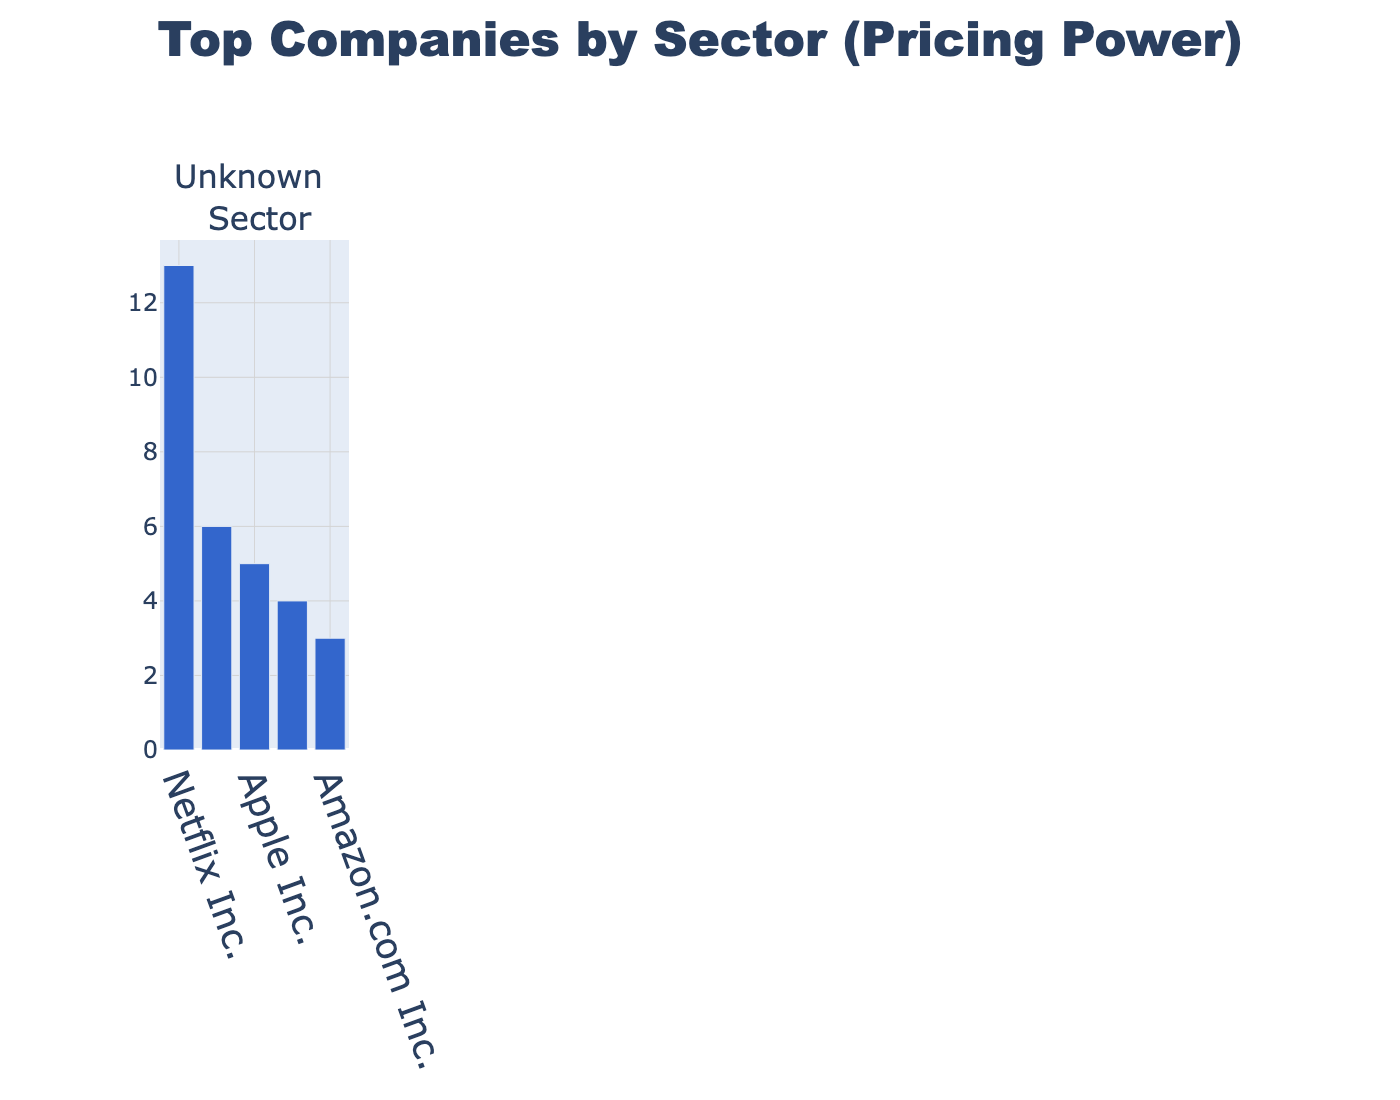

In [18]:
plot_top_companies_by_sector(df_positive_relevant, min_companies=3, title_suffix="(Pricing Power)", top_sectors=4)


### Companies Lacking of Pricing Power


This complementary chart shows companies most frequently mentioned in negative pricing power contexts, organized by sector and ranked by total mention volume. It identifies firms struggling with price competition, facing customer resistance to price increases, or operating in commoditized markets where pricing control is limited. Like the positive chart, sectors are ordered by their overall pricing power activity levels.


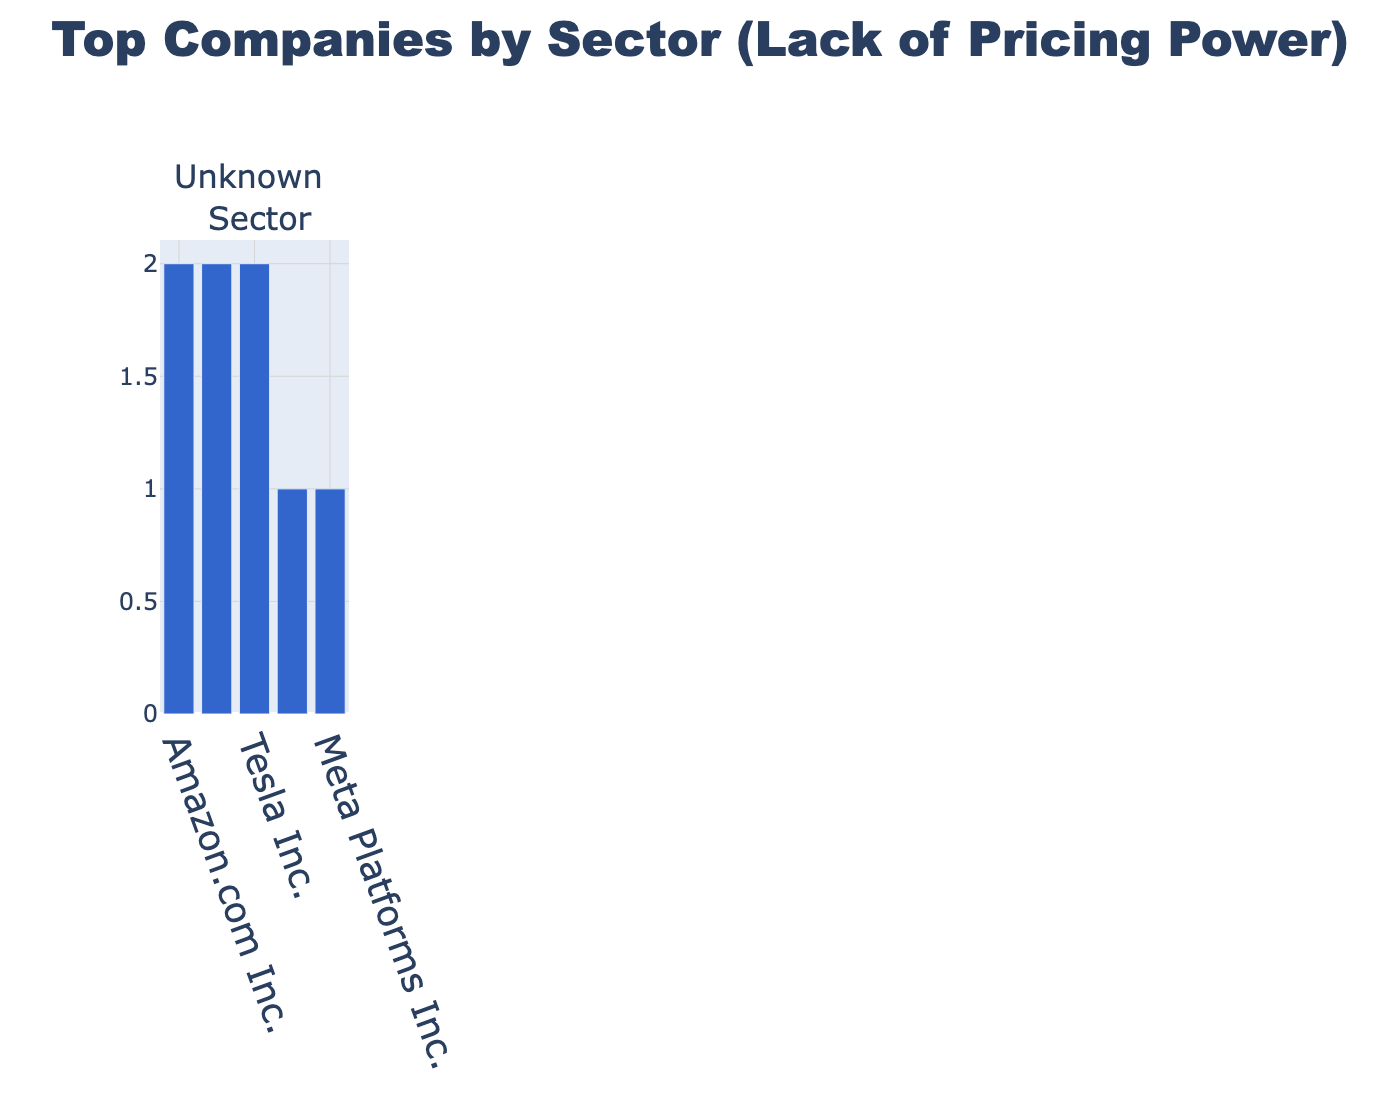

In [19]:
# min_companies lowered from 3 to 1: our cost-controlled universe is only
# 5 companies (one per sector), so no sector would ever have 3+ companies.
plot_top_companies_by_sector(df_negative_relevant, min_companies=3, title_suffix="(Lack of Pricing Power)", top_sectors=4)


## Pricing Power Confidence Analysis

This comprehensive assessment combines both positive and negative pricing power signals to create a confidence-based ranking system. The analysis provides:

- **Total Exposure**: Overall volume of pricing power related news coverage for each company
- **Confidence Scoring**: Relative proportion of positive versus negative pricing power mentions  
- **Relative Ranking**: How the top 30 most-mentioned companies compare against each other in terms of pricing power signals

The stacked bar chart shows the percentage breakdown of positive (green) versus negative (red) pricing power mentions, with a reference line at 50%. Companies to the right of the line show predominantly positive pricing power signals, while those to the left face more pricing challenges. The secondary chart on the right shows total mention volume, indicating which companies are most actively discussed in pricing power contexts.

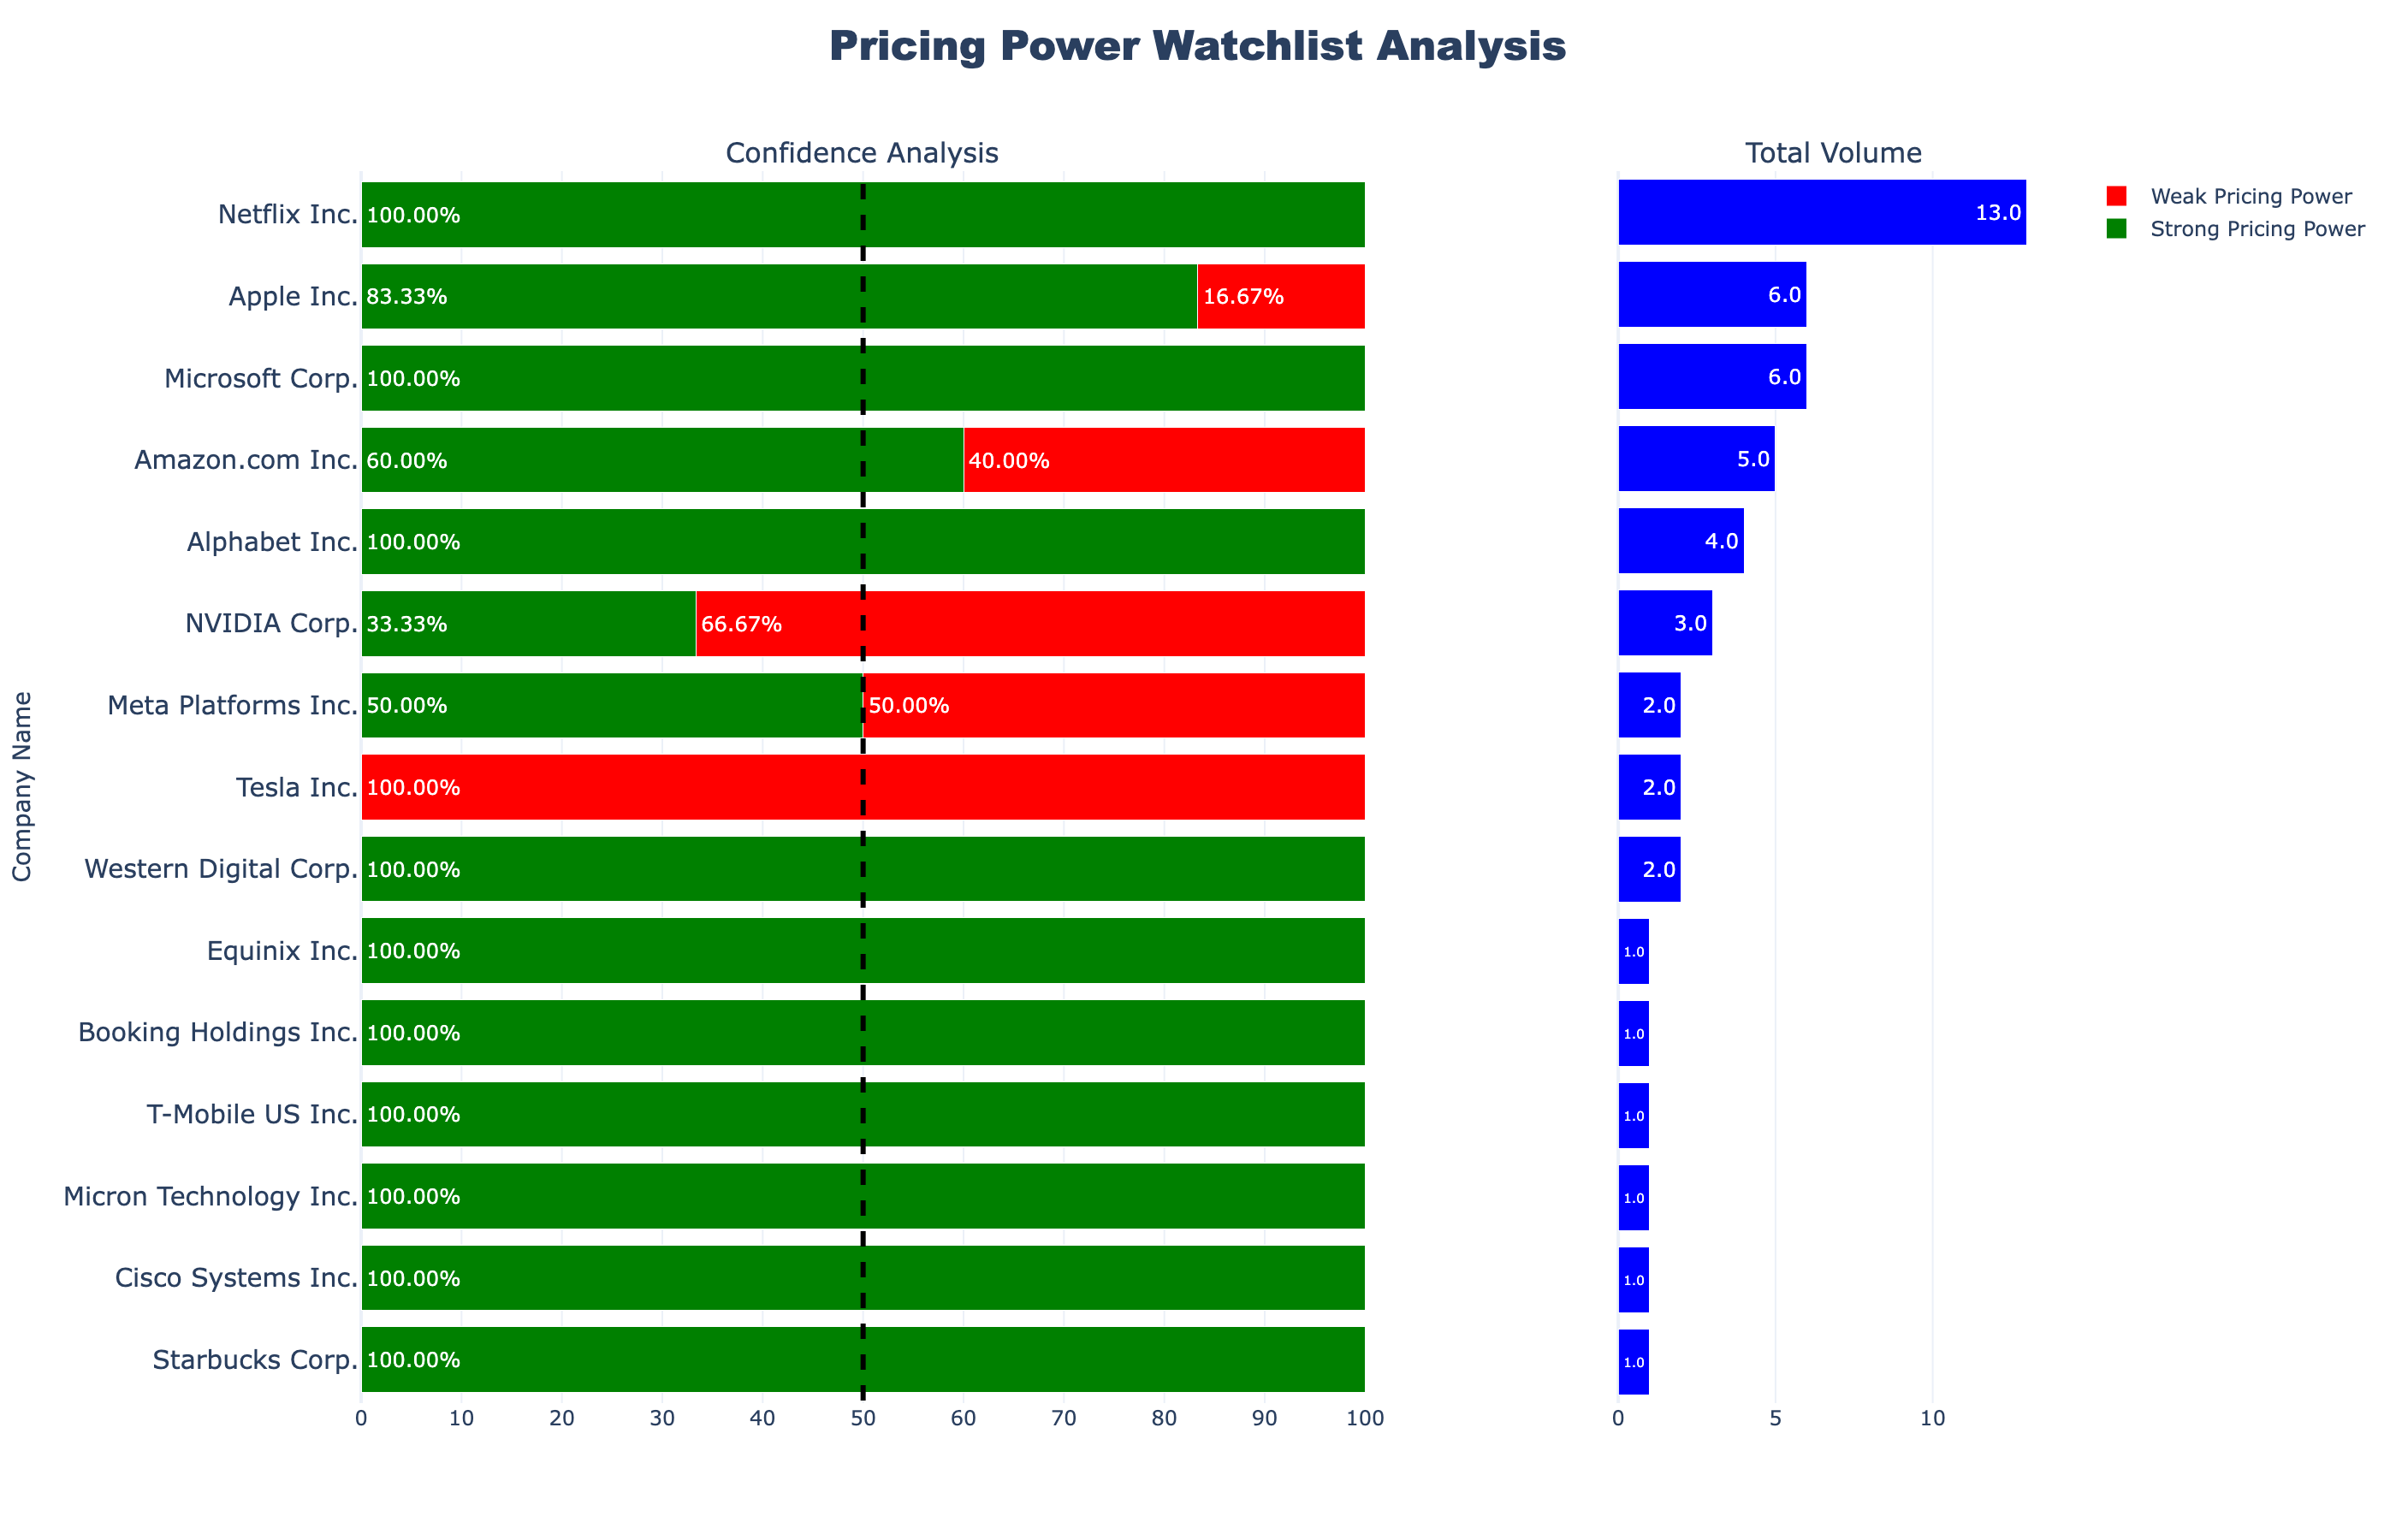

In [20]:
companies_basket = identify_basket_and_plot_confidence(df_positive_relevant, df_negative_relevant, basket_size=30, sector_column='Sector')


In [21]:
companies_basket.head()


,Company,positive_exp,negative_exp,total_exposure,Sector,positive_exp_pct,negative_exp_pct,headline_positive_exp,text_positive_exp,motivation_positive_exp,headline_negative_exp,text_negative_exp,motivation_negative_exp
0,Starbucks Corp.,1.0,0.0,1.0,Unknown,100.0,0.0,Research Alert: CFRA Keeps Hold Opinion On Sha...,"However, we're positive on SBUX's pricing powe...",Starbucks demonstrates pricing power through 4...,,,
1,Cisco Systems Inc.,1.0,0.0,1.0,Unknown,100.0,0.0,3 Mega-Trend Stocks to Boost Your Portfolio by...,"At the bottom line, the EPS exceeded the high ...",Cisco attributes part of its record gross marg...,,,
2,Micron Technology Inc.,1.0,0.0,1.0,Unknown,100.0,0.0,"Micron sees continued pricing strength, margin...","Micron sees continued pricing strength, margin...",Micron’s continued pricing strength and expand...,,,
3,T-Mobile US Inc.,1.0,0.0,1.0,Unknown,100.0,0.0,Comcast Poised For Value Growth - Citi Analyst...,Financial growth will likely be second-half we...,Comcast is expected to grow broadband revenue ...,,,
4,Booking Holdings Inc.,1.0,0.0,1.0,Unknown,100.0,0.0,"Airbnb's Marketing Efficiency, User Retention ...","""We believe it is benefiting from healthy secu...","Airbnb’s high host and guest retention, strong...",,,


## Temporal Pricing Power Analysis

This time-series analysis tracks how pricing power narratives evolve over time for companies in our basket. The weekly analysis reveals:

- **Narrative Trends**: How pricing power stories develop and change over time  
- **Net Positioning**: The balance between positive and negative pricing power mentions over time

Each line represents a company's "net pricing power exposure" (positive mentions minus negative mentions). Points above zero indicate weeks with net positive pricing power signals, while points below zero show weeks with net negative signals. Detailed hover information provides the specific news context driving each data point.



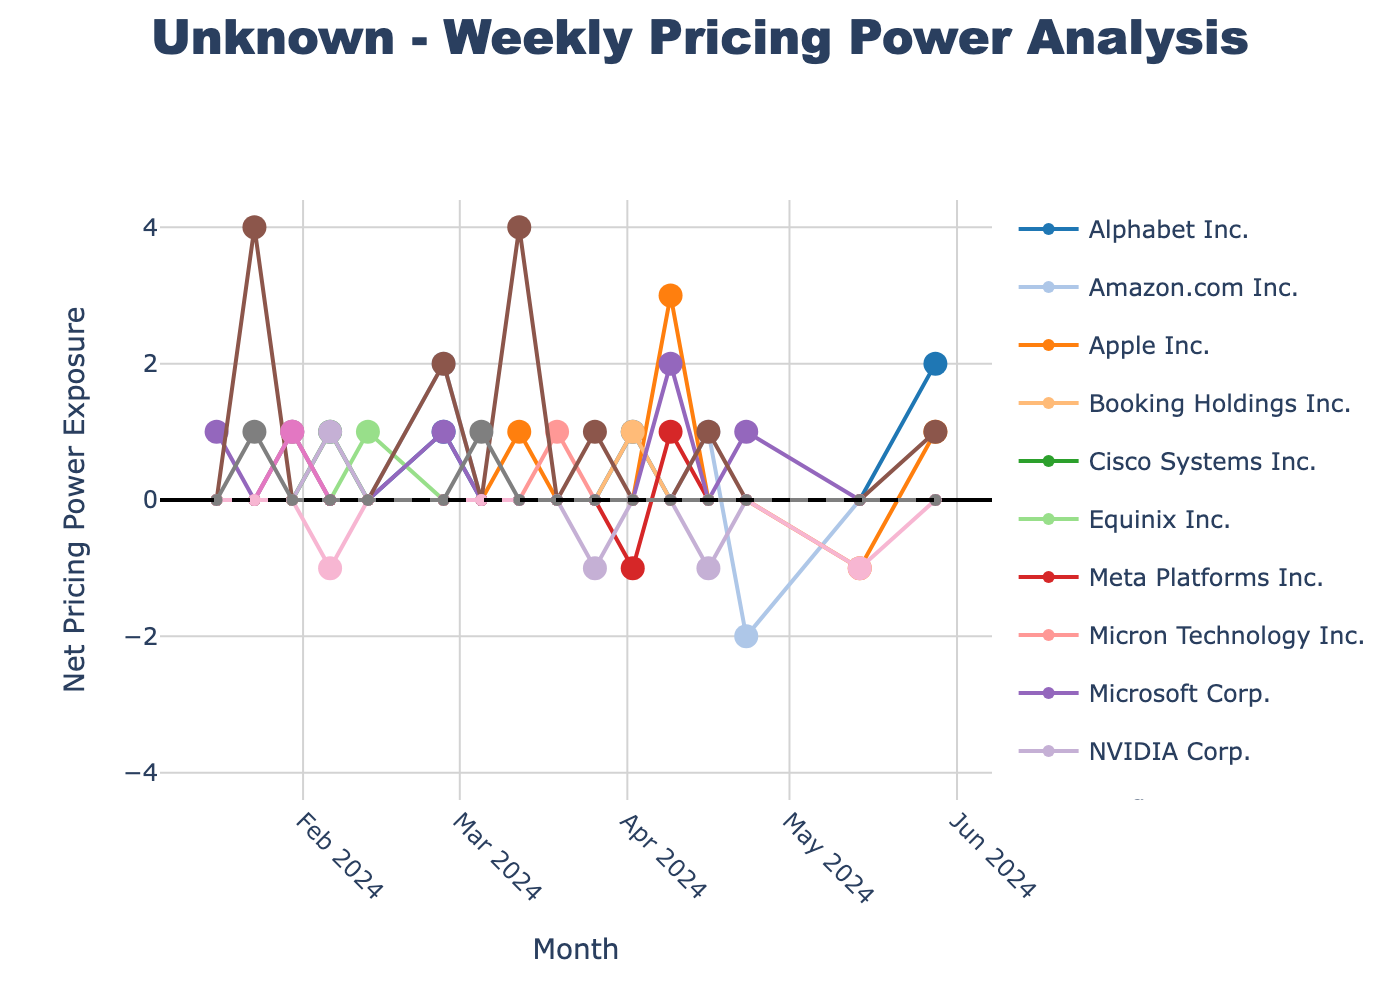

In [22]:
weekly_exposure = analyze_basket_weekly_with_labels(df_positive_relevant, df_negative_relevant, companies_basket, start_date, end_date, 'Sector')


## Key Insights and Market Stories

The temporal analysis reveals several notable pricing power stories:

**PepsiCo's Price Resistance**: PepsiCo's price hikes were met with significant resistance from major retailers like Carrefour, which stopped selling PepsiCo products in several European countries. The company experienced declining sales volume in Q1 2024, demonstrating the limits of pricing power when customers have alternatives.

**Quick Service Restaurant Challenges**: McDonald's and Starbucks faced customer backlash and reduced customer counts due to their price increases, indicating that even strong brands face constraints when pricing exceeds customer willingness to pay, particularly among price-sensitive consumers.

**Successful Pricing Power Examples**: Spotify demonstrated strong pricing power within the streaming industry, successfully raising subscription prices while justifying increases through improved product offerings and maintaining customer loyalty.

These examples illustrate that pricing power is dynamic and context-dependent, influenced by factors such as brand strength, competitive alternatives, and economic conditions.

## Export the Results

Export the data as Excel files for further analysis or to share with the team.

In [23]:
try:
    with pd.ExcelWriter(export_path, engine="openpyxl") as writer:
        df_positive_relevant.to_excel(writer, sheet_name="Positive Pricing Power", index=False)
        df_negative_relevant.to_excel(writer, sheet_name="Negative Pricing Power", index=False)
        companies_basket.to_excel(writer, sheet_name="Pricing Power Basket", index=False)
        weekly_exposure.to_excel(writer, sheet_name="Weekly Exposure Analysis", index=False)
    print(f"✅ Exported results to {export_path}")
except Exception as e:
    print(f"Warning while exporting to excel: {e}")


✅ Exported results to output/pricing_power_analysis_results.xlsx


In [24]:
print("Runtime:", datetime.datetime.now() - start)

Runtime: 0:05:16.118350
